# QM9-GWBSE Test & Evaluation

Evaluate trained models on the QM9-GWBSE test split and generate plots.


In [45]:
from pathlib import Path
import subprocess
import sys

repo_root = Path.cwd().resolve()
while repo_root != repo_root.parent and not (repo_root / 'pyproject.toml').exists():
    repo_root = repo_root.parent

xyz_dir = repo_root / 'data' / 'QM9GWBSE' / 'QM9_xyz_files'
metadata = repo_root / 'data' / 'QM9GWBSE' / 'metadata_e_exc_ss.csv'
splits_output = repo_root / 'data' / 'QM9GWBSE' / 'splits'
output_dir = repo_root / 'outputs' / 'qm9_testing'
split_methods = 'random'
if isinstance(split_methods, str):
    split_methods = [split_methods]
models_root = repo_root / 'models'
aim_vee_models_root = repo_root / 'models' / 'aim_vee_model'
model_runs = []
baseline_models = ['schnet', 'chemprop']
if any((models_root / model / split).exists() for model in baseline_models for split in split_methods):
    model_runs.append((models_root, baseline_models))
if any((aim_vee_models_root / 'mff_mlp' / split).exists() for split in split_methods):
    model_runs.append((aim_vee_models_root, ['mff_mlp']))
if not model_runs:
    model_runs.append((models_root, ['mff_mlp']))


In [47]:
for models_root, models_to_run in model_runs:
    cmd = [
        sys.executable,
        str(repo_root / 'scripts' / 'qm9_testing' / 'evaluate_models.py'),
        '--xyz-dir', str(xyz_dir),
        '--metadata', str(metadata),
        '--splits-output', str(splits_output),
        '--split-method', ','.join(split_methods),
        '--models-root', str(models_root),
        '--qemfi-scaler-path', str(models_root / 'mff_mlp' / split_methods[0] / 'qemfi_scaler.pkl'),
        '--output-dir', str(output_dir),
        '--models', ','.join(models_to_run),
    ]
    subprocess.run(cmd, check=True)


Using device: cpu


/Users/lohitakshbadarala/Desktop/AIM-VEE/scripts/qm9_testing/evaluate_models.py:142: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(model_pat

schnet metrics: {'mae': 0.11862299591302872, 'rmse': 0.1875015000442265, 'r2': 0.9761708378791809}
chemprop metrics: {'mae': 0.1810992956161499, 'rmse': 0.3177176601833586, 'r2': 0.9315800666809082}
Saved metrics to /Users/lohitakshbadarala/Desktop/AIM-VEE/outputs/qm9_testing/random/summary.csv
Using device: cpu


/opt/anaconda3/envs/aim_vee/lib/python3.10/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.7.2 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/opt/anaconda3/envs/aim_vee/lib/python3.10/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator PCA from version 1.7.2 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/Users/lohitakshbadarala/Desktop/AIM-VEE/scripts/qm9_testing/evaluate_models.py:258: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which use

mff_mlp metrics: {'mae': 0.19681768119335175, 'rmse': 0.27602705227054636, 'r2': 0.9483579993247986}
Saved metrics to /Users/lohitakshbadarala/Desktop/AIM-VEE/outputs/qm9_testing/random/summary.csv


In [ ]:
cmd = [
    sys.executable,
    str(repo_root / 'scripts' / 'qm9_testing' / 'plot_results.py'),
    '--results-dir', str(output_dir),
    '--split-method', split_method,
]
subprocess.run(cmd, check=True)


Saved plots to /Users/lohitakshbadarala/Desktop/AIM-VEE/outputs/qm9_testing/bemis-murcko/plots


CompletedProcess(args=['/opt/anaconda3/envs/aim_vee/bin/python', '/Users/lohitakshbadarala/Desktop/AIM-VEE/scripts/qm9_testing/plot_results.py', '--results-dir', '/Users/lohitakshbadarala/Desktop/AIM-VEE/outputs/qm9_testing', '--split-method', 'bemis-murcko'], returncode=0)

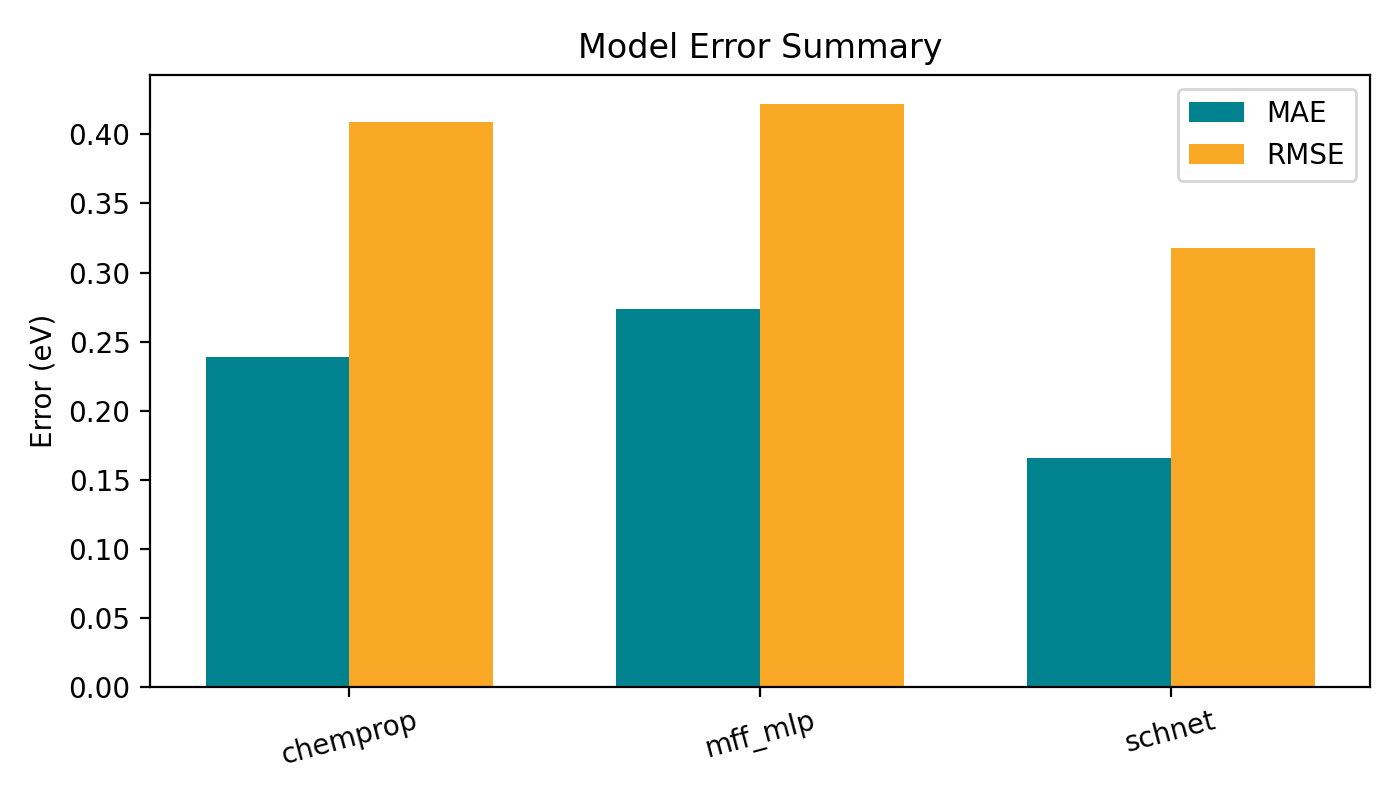

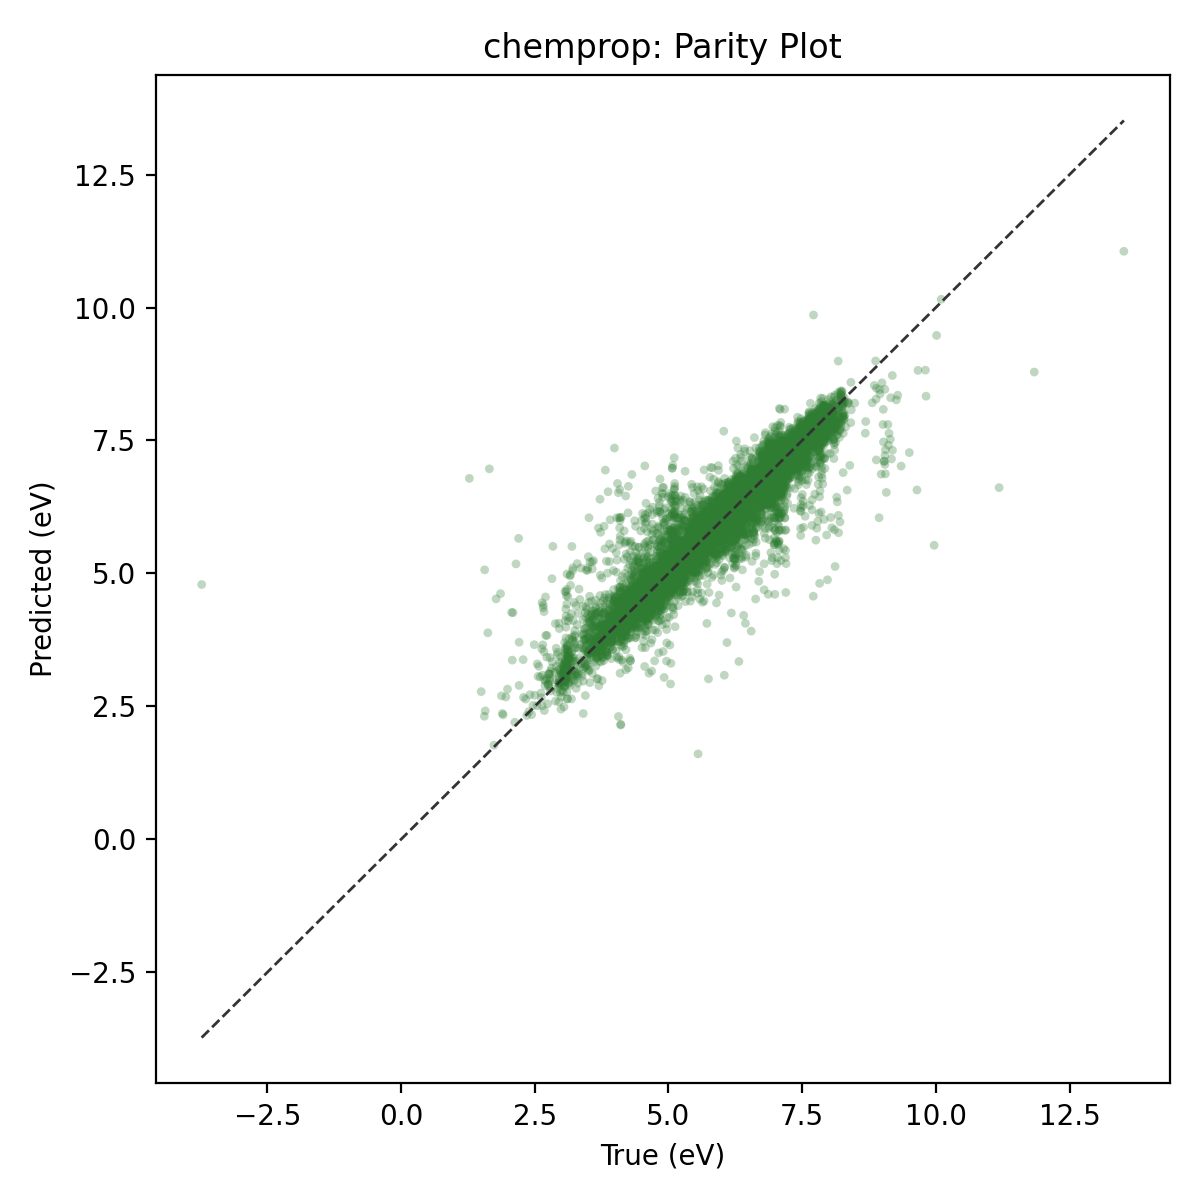

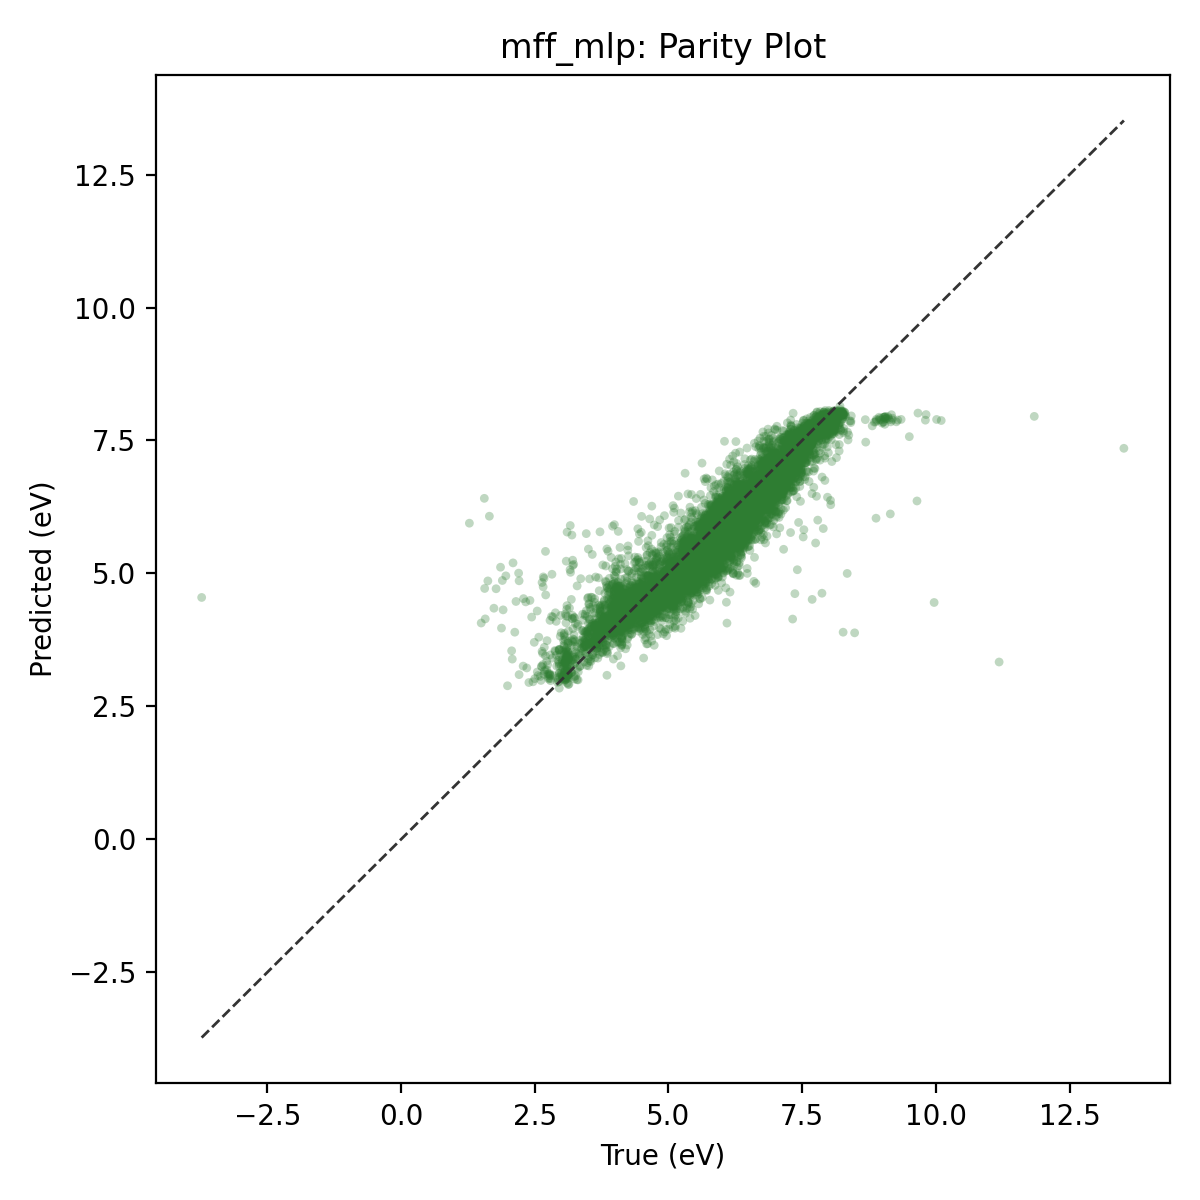

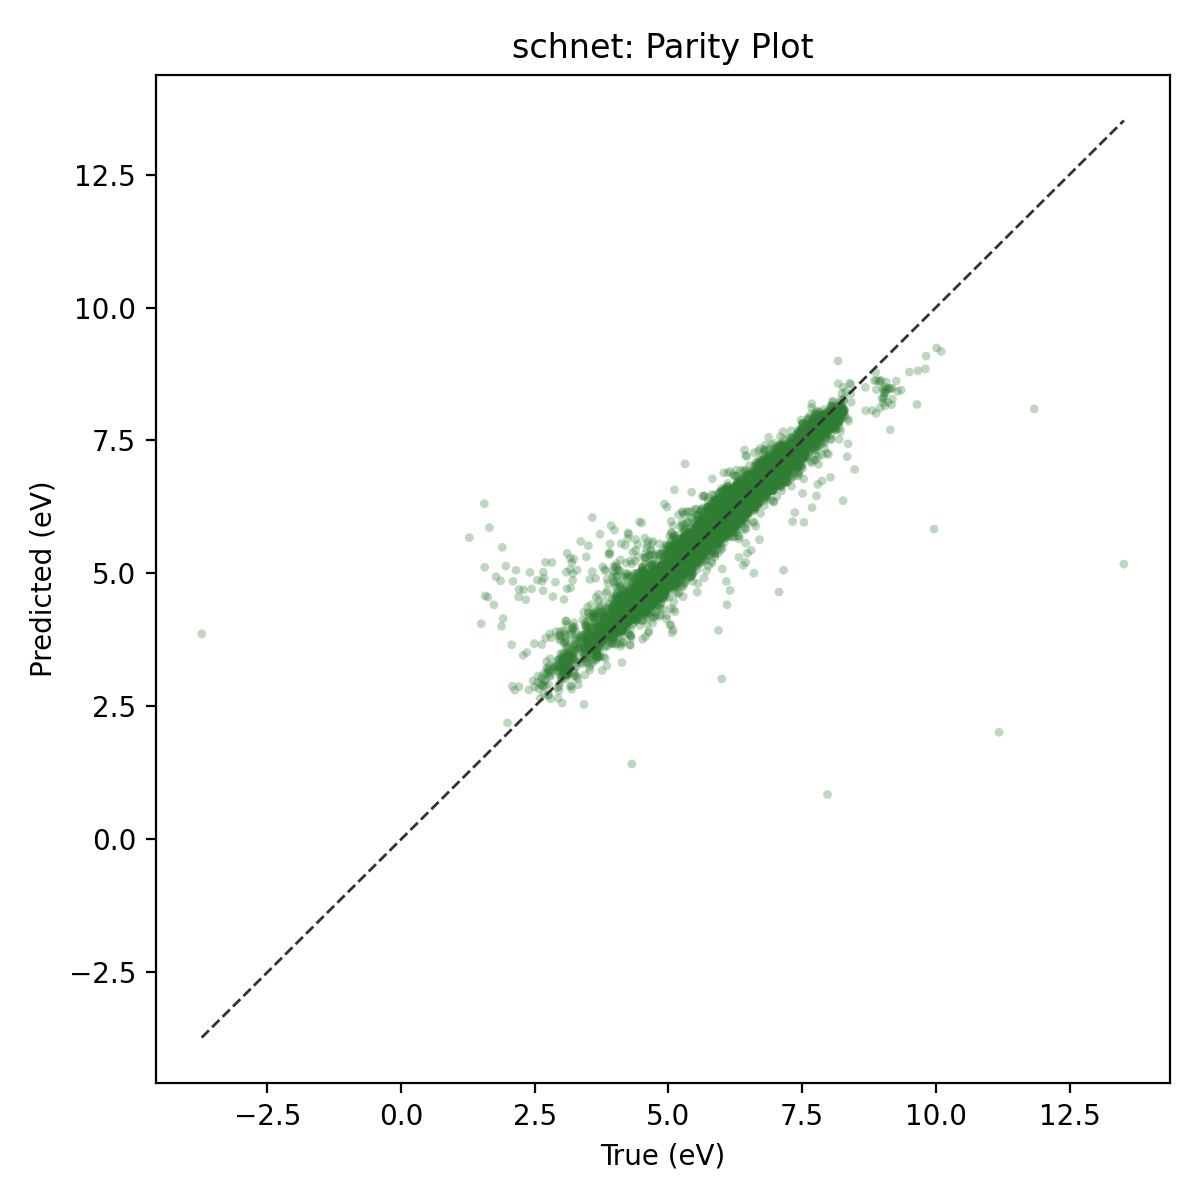

In [ ]:
from IPython.display import Image, display

plots_dir = output_dir / split_method / 'plots'
summary_plot = plots_dir / 'metrics_summary.png'
if summary_plot.exists():
    display(Image(filename=str(summary_plot)))

for path in sorted(plots_dir.glob('parity_*.png'))[:4]:
    display(Image(filename=str(path)))
